In [ ]:
# Cross-Country Solar Potential Comparison

Objective: Compare solar potential across Benin, Sierra Leone, and Togo  
Tasks: Metric comparison, statistical testing, and insights generation

In [2]:
# === NOTEBOOK CONFIGURATION ===
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

print("Notebook configuration completed!")

Notebook configuration completed!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

print("All libraries imported successfully!")

All libraries imported successfully!


In [6]:
# === LOAD CLEANED DATA FROM ALL COUNTRIES ===
print("Loading cleaned datasets...")

# Load each country's cleaned data
benin = pd.read_csv('../data/benin_clean.csv')
sierra_leone = pd.read_csv('../data/sierraleone_clean.csv')
togo = pd.read_csv('../data/togo_clean.csv')

print(f"Benin shape: {benin.shape}")
print(f"Sierra Leone shape: {sierra_leone.shape}")
print(f"Togo shape: {togo.shape}")

# Add country identifier to each dataset
benin['Country'] = 'Benin'
sierra_leone['Country'] = 'Sierra Leone'
togo['Country'] = 'Togo'

# Combine all data into one DataFrame
all_data = pd.concat([benin, sierra_leone, togo], ignore_index=True)

print(f"Combined dataset shape: {all_data.shape}")
print(f"Countries in dataset: {all_data['Country'].unique()}")

Loading cleaned datasets...
Benin shape: (517860, 22)
Sierra Leone shape: (509308, 22)
Togo shape: (516349, 22)
Combined dataset shape: (1543517, 23)
Countries in dataset: ['Benin' 'Sierra Leone' 'Togo']


In [7]:
# === CREATE SUMMARY STATISTICS TABLE ===
print("=== SUMMARY STATISTICS BY COUNTRY ===")

# Key solar metrics to compare
key_metrics = ['GHI', 'DNI', 'DHI']

# Calculate summary statistics for each country
summary_stats = all_data.groupby('Country')[key_metrics].agg(['mean', 'median', 'std', 'min', 'max'])

# Display the summary table
print("\nSummary Statistics (Mean, Median, Standard Deviation):")
display(summary_stats)

# Create a simplified table for the report
simple_summary = all_data.groupby('Country')[key_metrics].agg(['mean', 'median', 'std'])
print("\nSimplified Summary Table:")
display(simple_summary)

=== SUMMARY STATISTICS BY COUNTRY ===

Summary Statistics (Mean, Median, Standard Deviation):


GHI                                          DNI         \
                    mean median         std   min     max        mean median   
Country                                                                        
Benin         236.234508    0.7  328.288787 -11.1  1233.0  166.896673   -0.1   
Sierra Leone  185.000024   -0.4  279.019460 -15.9  1097.0  104.128943   -0.1   
Togo          223.859675    0.5  317.306277 -12.7  1198.0  147.975931    0.0   

                                             DHI                           \
                     std  min    max        mean median         std   min   
Country                                                                     
Benin         262.081997 -7.8  952.3  111.656477    0.5  153.099749 -12.6   
Sierra Leone  200.954182 -7.8  772.3  108.104278   -0.6  153.691835 -16.7   
Togo          247.683690  0.0  904.1  112.781249    1.5  151.571744   0.0   

                     
                max  
Country              
Benin         591.4  
Sierra Leone  590.5  
Togo          586.0


Simplified Summary Table:


GHI                            DNI                     \
                    mean median         std        mean median         std   
Country                                                                      
Benin         236.234508    0.7  328.288787  166.896673   -0.1  262.081997   
Sierra Leone  185.000024   -0.4  279.019460  104.128943   -0.1  200.954182   
Togo          223.859675    0.5  317.306277  147.975931    0.0  247.683690   

                     DHI                     
                    mean median         std  
Country                                      
Benin         111.656477    0.5  153.099749  
Sierra Leone  108.104278   -0.6  153.691835  
Togo          112.781249    1.5  151.571744

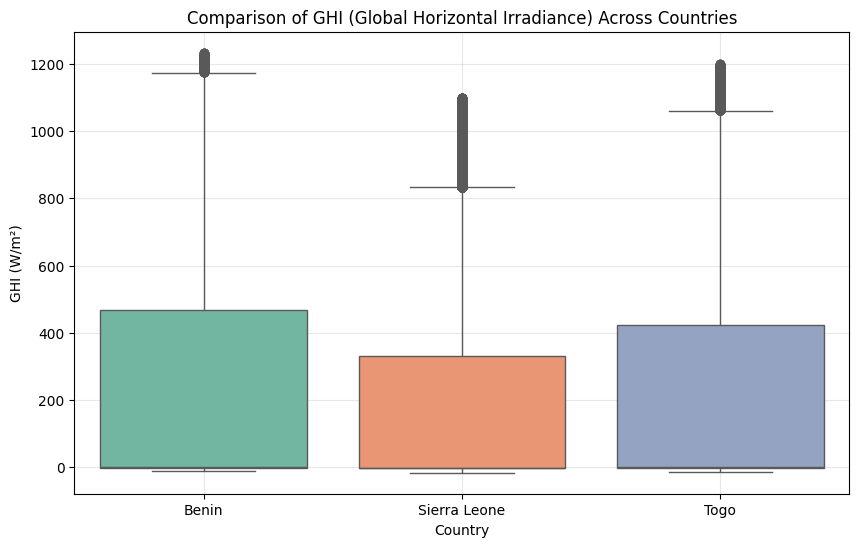

=== GHI INSIGHTS ===
Countries ranked by average GHI:
  Benin: 236.23 W/m²
  Togo: 223.86 W/m²
  Sierra Leone: 185.00 W/m²


In [8]:
# === BOXPLOT COMPARISON - GHI ===
plt.figure(figsize=(10, 6))
sns.boxplot(x='Country', y='GHI', data=all_data, palette='Set2')
plt.title('Comparison of GHI (Global Horizontal Irradiance) Across Countries')
plt.xlabel('Country')
plt.ylabel('GHI (W/m²)')
plt.grid(True, alpha=0.3)
plt.show()

# Add some statistical insights
print("=== GHI INSIGHTS ===")
ghi_means = all_data.groupby('Country')['GHI'].mean().sort_values(ascending=False)
print("Countries ranked by average GHI:")
for country, mean_val in ghi_means.items():
    print(f"  {country}: {mean_val:.2f} W/m²")

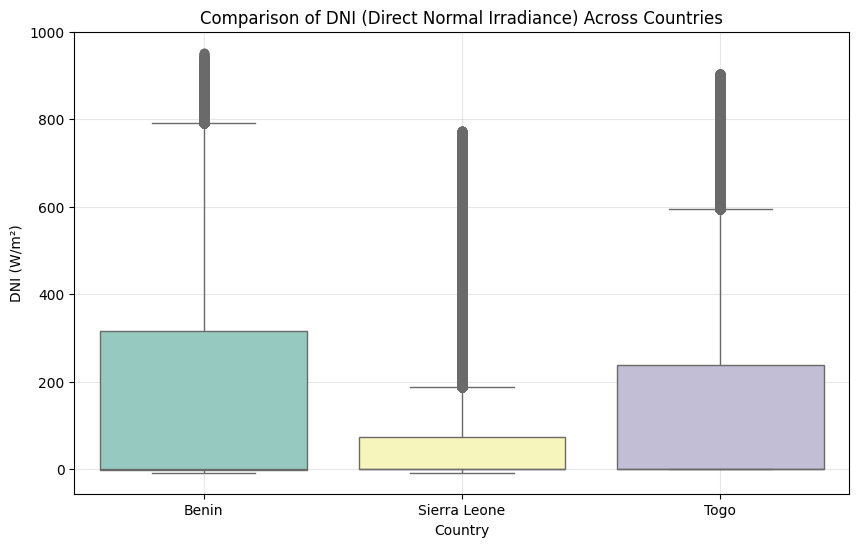

=== DNI INSIGHTS ===
Countries ranked by average DNI:
  Benin: 166.90 W/m²
  Togo: 147.98 W/m²
  Sierra Leone: 104.13 W/m²


In [9]:
# === BOXPLOT COMPARISON - DNI ===
plt.figure(figsize=(10, 6))
sns.boxplot(x='Country', y='DNI', data=all_data, palette='Set3')
plt.title('Comparison of DNI (Direct Normal Irradiance) Across Countries')
plt.xlabel('Country')
plt.ylabel('DNI (W/m²)')
plt.grid(True, alpha=0.3)
plt.show()

print("=== DNI INSIGHTS ===")
dni_means = all_data.groupby('Country')['DNI'].mean().sort_values(ascending=False)
print("Countries ranked by average DNI:")
for country, mean_val in dni_means.items():
    print(f"  {country}: {mean_val:.2f} W/m²")

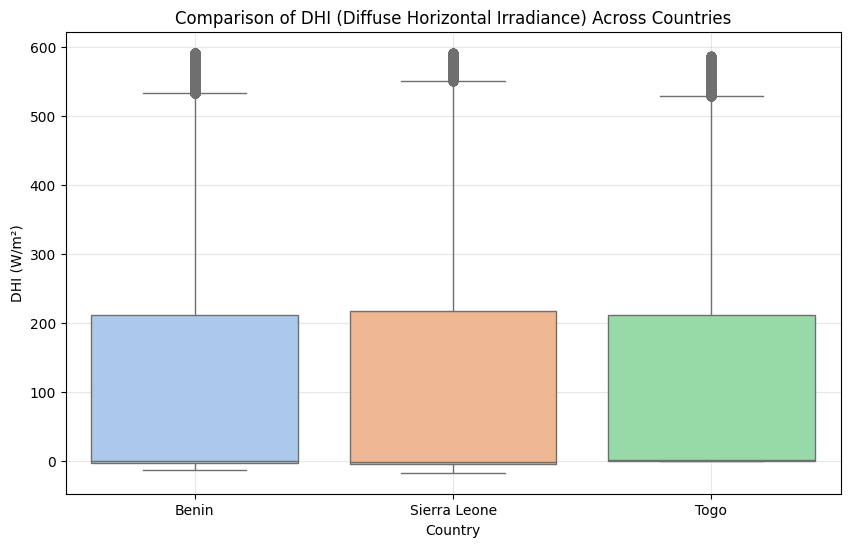

=== DHI INSIGHTS ===
Countries ranked by average DHI:
  Togo: 112.78 W/m²
  Benin: 111.66 W/m²
  Sierra Leone: 108.10 W/m²


In [10]:
# === BOXPLOT COMPARISON - DHI ===
plt.figure(figsize=(10, 6))
sns.boxplot(x='Country', y='DHI', data=all_data, palette='pastel')
plt.title('Comparison of DHI (Diffuse Horizontal Irradiance) Across Countries')
plt.xlabel('Country')
plt.ylabel('DHI (W/m²)')
plt.grid(True, alpha=0.3)
plt.show()

print("=== DHI INSIGHTS ===")
dhi_means = all_data.groupby('Country')['DHI'].mean().sort_values(ascending=False)
print("Countries ranked by average DHI:")
for country, mean_val in dhi_means.items():
    print(f"  {country}: {mean_val:.2f} W/m²")

In [12]:
# === STATISTICAL SIGNIFICANCE TESTING ===
print("=== STATISTICAL SIGNIFICANCE TEST (ANOVA) ===")

# Extract GHI values for each country
benin_ghi = benin['GHI'].dropna()
sierra_ghi = sierra_leone['GHI'].dropna()
togo_ghi = togo['GHI'].dropna()

# Perform one-way ANOVA test
# H0: The mean GHI is the same for all countries
# H1: At least one country has a different mean GHI
f_stat, p_value = stats.f_oneway(benin_ghi, sierra_ghi, togo_ghi)

print(f"ANOVA Results for GHI:")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpret the results
alpha = 0.05  # Significance level
if p_value < alpha:
    print(" Result: Statistically SIGNIFICANT - There are real differences in solar potential between countries.")
    print("   The observed differences in GHI are not due to random chance.")
else:
    print(" Result: Not statistically significant - Differences could be due to random variation.")

print(f"\nInterpretation: Since p-value {p_value:.4f} is {'<' if p_value < alpha else '>='} {alpha}, we {'reject' if p_value < alpha else 'fail to reject'} the null hypothesis.")

=== STATISTICAL SIGNIFICANCE TEST (ANOVA) ===
ANOVA Results for GHI:
F-statistic: 3833.1842
P-value: 0.0000
 Result: Statistically SIGNIFICANT - There are real differences in solar potential between countries.
   The observed differences in GHI are not due to random chance.

Interpretation: Since p-value 0.0000 is < 0.05, we reject the null hypothesis.


=== COUNTRY RANKING BY SOLAR POTENTIAL ===


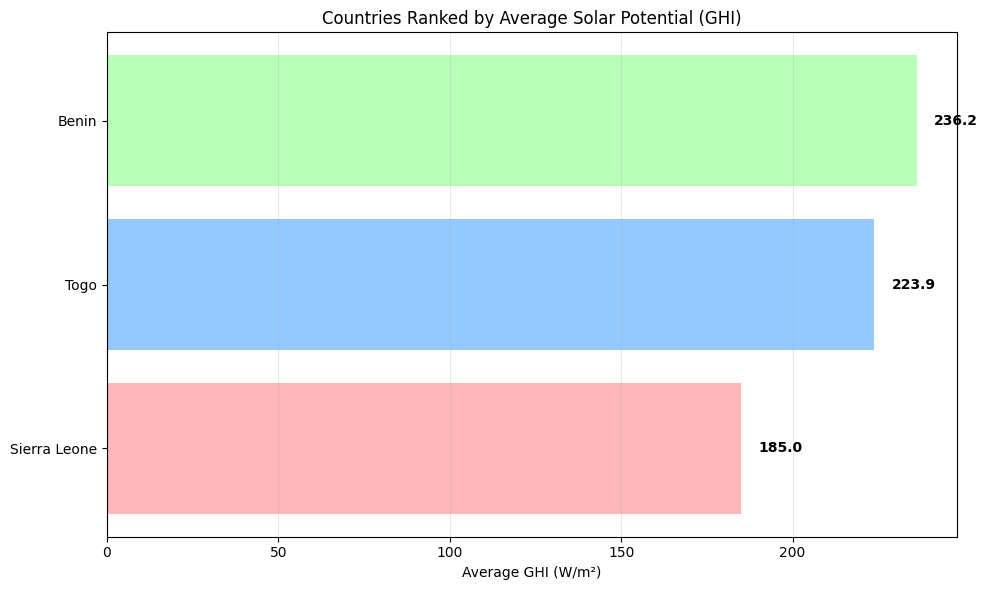

Final Ranking:
1. Sierra Leone: 185.00 W/m²
2. Togo: 223.86 W/m²
3. Benin: 236.23 W/m²


In [13]:
# === VISUAL SUMMARY - RANKING BY AVERAGE GHI ===
print("=== COUNTRY RANKING BY SOLAR POTENTIAL ===")

# Calculate average GHI for ranking
avg_ghi_by_country = all_data.groupby('Country')['GHI'].mean().sort_values(ascending=True)

# Create horizontal bar chart for better readability
plt.figure(figsize=(10, 6))
colors = ['#ff9999', '#66b3ff', '#99ff99']  # Red, Blue, Green
bars = plt.barh(avg_ghi_by_country.index, avg_ghi_by_country.values, color=colors, alpha=0.7)

# Add value labels on bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 5, bar.get_y() + bar.get_height()/2, f'{width:.1f}', 
             ha='left', va='center', fontweight='bold')

plt.xlabel('Average GHI (W/m²)')
plt.title('Countries Ranked by Average Solar Potential (GHI)')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("Final Ranking:")
for i, (country, value) in enumerate(avg_ghi_by_country.items(), 1):
    print(f"{i}. {country}: {value:.2f} W/m²")

In [14]:
# === KEY OBSERVATIONS & INSIGHTS ===
print("=== KEY OBSERVATIONS & RECOMMENDATIONS ===")

# Calculate some additional insights
ghi_variability = all_data.groupby('Country')['GHI'].std()
best_ghi_country = avg_ghi_by_country.idxmax()
most_consistent_country = ghi_variability.idxmin()
most_variable_country = ghi_variability.idxmax()

print("\n **Key Findings:**")
print(f"• **Highest Solar Potential**: {best_ghi_country} with average GHI of {avg_ghi_by_country[best_ghi_country]:.1f} W/m²")
print(f"• **Most Consistent Solar Resource**: {most_consistent_country} (lowest variability)")
print(f"• **Most Variable Solar Resource**: {most_variable_country} (highest variability)")
print(f"• **Statistical Significance**: {'Yes' if p_value < 0.05 else 'No'} (p-value: {p_value:.4f})")

print("\n **Business Recommendations:**")
print(f"• **Primary Investment Target**: {best_ghi_country} - strongest overall solar potential")
print(f"• **Secondary Consideration**: {most_consistent_country} - most predictable energy generation")
print(f"• **Risk Consideration**: {most_variable_country} may require energy storage solutions")

=== KEY OBSERVATIONS & RECOMMENDATIONS ===

 **Key Findings:**
• **Highest Solar Potential**: Benin with average GHI of 236.2 W/m²
• **Most Consistent Solar Resource**: Sierra Leone (lowest variability)
• **Most Variable Solar Resource**: Benin (highest variability)
• **Statistical Significance**: Yes (p-value: 0.0000)

 **Business Recommendations:**
• **Primary Investment Target**: Benin - strongest overall solar potential
• **Secondary Consideration**: Sierra Leone - most predictable energy generation
• **Risk Consideration**: Benin may require energy storage solutions


=== ADDITIONAL ANALYSIS: TEMPERATURE COMPARISON ===


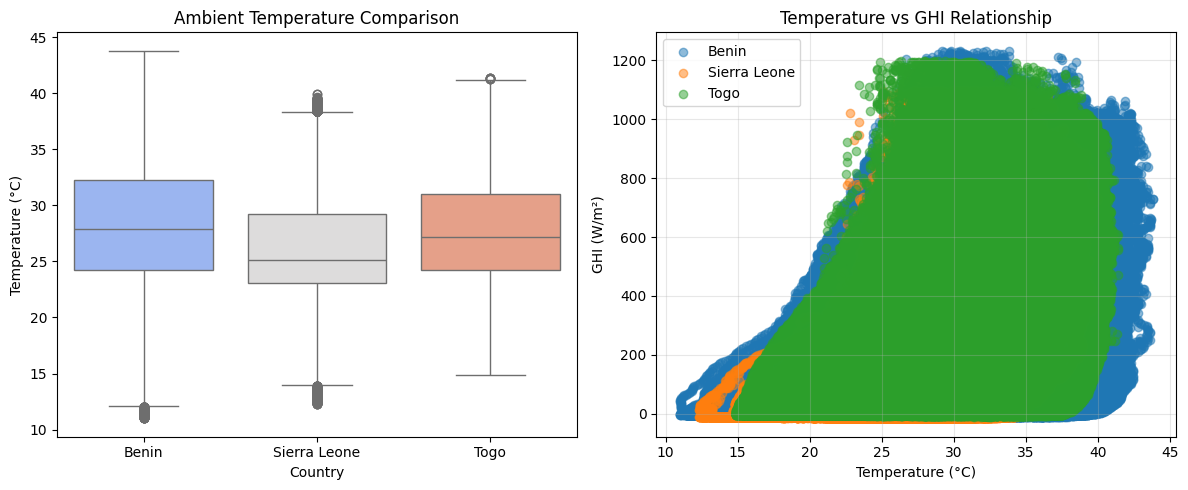

Average Temperatures by Country:
  Benin: 28.1°C
  Sierra Leone: 26.2°C
  Togo: 27.7°C


In [15]:
# === TEMPERATURE COMPARISON ===
print("=== ADDITIONAL ANALYSIS: TEMPERATURE COMPARISON ===")

if 'Tamb' in all_data.columns:
    plt.figure(figsize=(12, 5))
    
    # Subplot 1: Boxplot
    plt.subplot(1, 2, 1)
    sns.boxplot(x='Country', y='Tamb', data=all_data, palette='coolwarm')
    plt.title('Ambient Temperature Comparison')
    plt.xlabel('Country')
    plt.ylabel('Temperature (°C)')
    
    # Subplot 2: Scatter plot
    plt.subplot(1, 2, 2)
    for country in all_data['Country'].unique():
        country_data = all_data[all_data['Country'] == country]
        plt.scatter(country_data['Tamb'], country_data['GHI'], alpha=0.5, label=country)
    
    plt.title('Temperature vs GHI Relationship')
    plt.xlabel('Temperature (°C)')
    plt.ylabel('GHI (W/m²)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Temperature insights
    temp_means = all_data.groupby('Country')['Tamb'].mean()
    print("Average Temperatures by Country:")
    for country, temp in temp_means.items():
        print(f"  {country}: {temp:.1f}°C")